In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic - Copy.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Filling Age missing values with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Droping Cabin column as it has too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Filling Embarked with most common value as it has only 2 missing values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Checking if missing values are gone
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

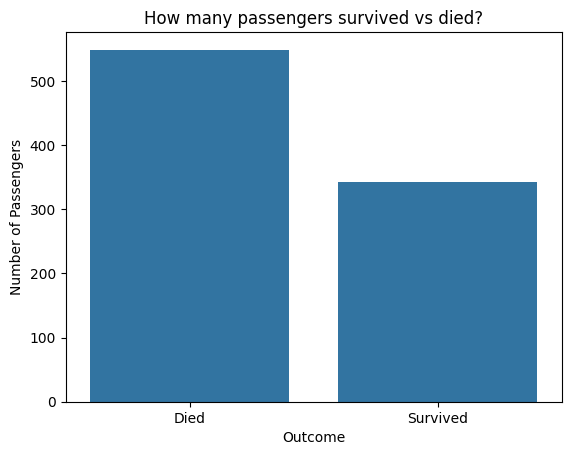

In [6]:
# survival count
sns.countplot(x='Survived', data=df)
plt.title('How many passengers survived vs died?')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')
plt.show()

In [7]:
print(df['Survived'].value_counts())
print()
print(df['Survived'].value_counts(normalize=True) * 100)

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


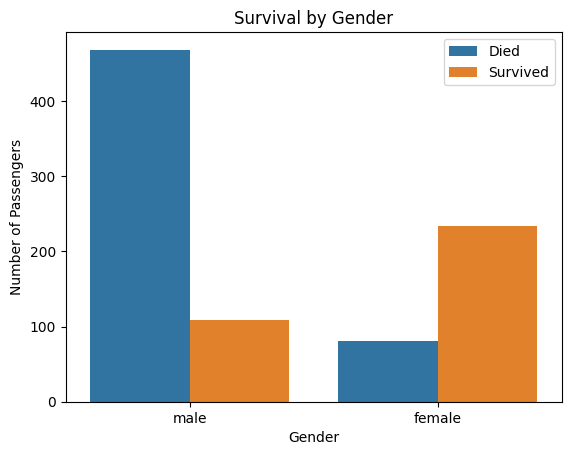

In [8]:
# survival rate by gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

In [9]:
print(df.groupby('Sex')['Survived'].value_counts(normalize=True) * 100)

Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64


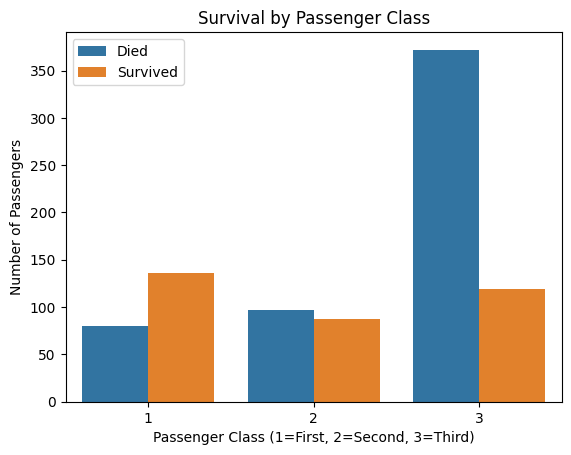

In [10]:
# survival rate by passenger class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Number of Passengers')
plt.show()

In [11]:
print(df.groupby('Pclass')['Survived'].value_counts(normalize=True) * 100)

Pclass  Survived
1       1           62.962963
        0           37.037037
2       0           52.717391
        1           47.282609
3       0           75.763747
        1           24.236253
Name: proportion, dtype: float64


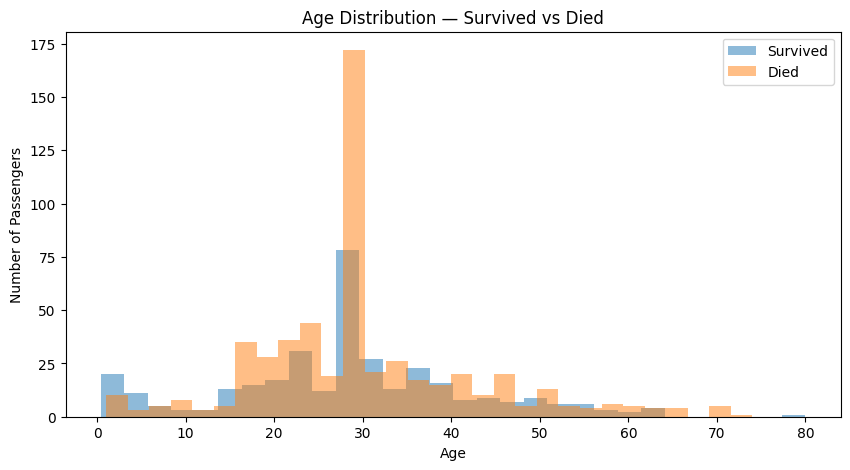

In [12]:
# age distribution
plt.figure(figsize=(10, 5))
plt.hist(df[df['Survived'] == 1]['Age'], alpha=0.5, label='Survived', bins=30)
plt.hist(df[df['Survived'] == 0]['Age'], alpha=0.5, label='Died', bins=30)
plt.title('Age Distribution — Survived vs Died')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [13]:
# age group analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 10, 18, 30, 50, 80], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
print(df.groupby('AgeGroup')['Survived'].value_counts(normalize=True) * 100)

AgeGroup     Survived
Child        1           59.375000
             0           40.625000
Teen         0           57.333333
             1           42.666667
Young Adult  0           66.890380
             1           33.109620
Adult        0           57.676349
             1           42.323651
Senior       0           65.625000
             1           34.375000
Name: proportion, dtype: float64
